Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingRegressor

## Data Cleaning and Analysis

In [2]:
# Load dataset
df = pd.read_csv('/content/dataset.csv')

In [3]:
# Analyze dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [4]:
# Look into original dataset
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
# Drop unamed column
df = df.drop(columns=['Unnamed: 0'])
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


The "Unnamed : 0" column was removed from the data set because it was just showing index values, which automaticaly are added in a pandas data frame.

In [6]:
# Check for missing values
df.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [7]:
# Find row with missing values
df[df.isnull().any(axis=1)]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [8]:
# Remove the row with missing values
df = df.dropna()
df.isnull().sum()

,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


A row with missing values in features artists, album_name, and track_name was removed. The row also had a "duration_ms" value of 0, indicating that it is bad data. Since only one row was affected, its removal does not meaningfully impact the dataset but improves overall data quality.

In [9]:
# Check to make sure no other rows have a duration of 0 ms
df[df['duration_ms'] == 0]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre


## Emotion Feature Creation

Two approaches: Data-driven using K-means clustering and theory driven using predefined threshold

Both approaches use valence and energy to determine the emotional category because this has been a proven strategy in previous reserach.

In [10]:
# K-means
kmeans = KMeans(n_clusters=4, random_state = 42)
kmeans.fit(df[['energy', 'valence']])
df['cluster'] = kmeans.fit_predict(df[['energy', 'valence']])

In [11]:
# Determine thresholds for each category
df.groupby('cluster')[['energy', 'valence']].mean()

,energy,valence
cluster,,
0,0.816730,0.290761
1,0.806658,0.752104
2,0.294751,0.213892
3,0.482406,0.596653


In [12]:
# Map each cluster with correct label
cluser_map = {
    0: 'anger',
    1: 'happiness',
    2: 'sadness',
    3: 'calmness'
}

# Create new feature to hold emotion labels by K-means
df['emotion_kmeans'] = df['cluster'].map(cluser_map)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster,emotion_kmeans
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3,calmness
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2,sadness
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,2,sadness
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,2,sadness
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,2,sadness


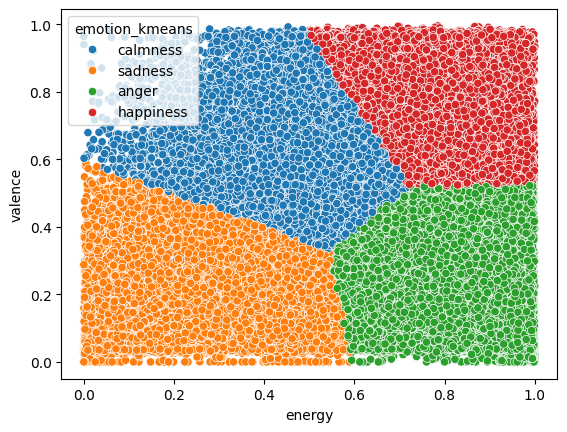

In [13]:
# K-Means Clustering visualization
sns.scatterplot(data = df, x = 'energy', y = 'valence', hue = 'emotion_kmeans')
plt.show()

In [14]:
# Create function to assign emotion category

def get_emotion(row):
  if row['energy'] >= 0.5 and row['valence'] >= 0.5:
    emotion = 'happiness'
  elif row['energy'] >= 0.5 and row['valence'] < 0.5:
    emotion = 'anger'
  elif row['energy'] < 0.5 and row['valence'] < 0.5:
    emotion = 'sadness'
  else:
    emotion = "calmness"
  return emotion

In [15]:
# Create new feature to hold emotion based off of theory

df['emotion'] = df.apply(get_emotion, axis=1)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster,emotion_kmeans,emotion
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3,calmness,calmness
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2,sadness,sadness
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,2,sadness,sadness
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,2,sadness,sadness
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,2,sadness,sadness


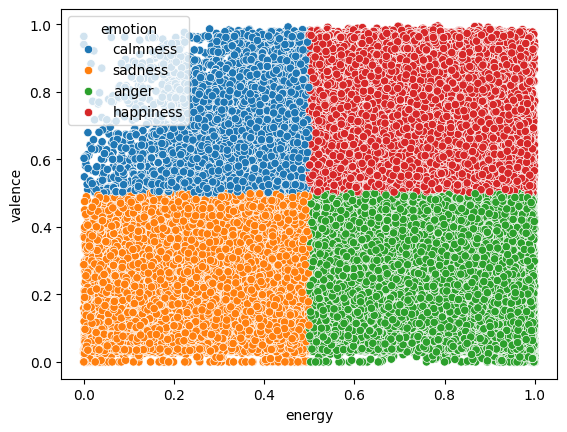

In [16]:
# Rule-Based Approach visualization
sns.scatterplot(data = df, x = 'energy', y = 'valence', hue = 'emotion')
plt.show()

Both approaches produced different clusters, but the data-driven approach follows a similar structure by having each corner represent the same emotion category.

Test Both Emotion features with Random Forest and SVM

In [18]:
# Train/Test Split for emotion

X = df.drop(columns=['emotion', 'emotion_kmeans', 'cluster', 'track_id', 'artists', 'album_name', 'track_name'])
X = pd.get_dummies(X, columns = ['track_genre'], drop_first = True)
y1 = df['emotion']

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y1, test_size = 0.3, random_state = 42,
    stratify = y1
)

In [19]:
# Train/Test Split for emotion_kmeans

y2 = df['emotion_kmeans']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y2, test_size = 0.3, random_state = 42,
    stratify = y2
)

In [30]:
# Random Forest for emotion

rf1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf1.fit(X_train1, y_train1)

y_pred1 = rf1.predict(X_test1)
accuracy1 = accuracy_score(y_test1, y_pred1)
print(accuracy1)

1.0


In [31]:
# Random Forest for emotion_kmeans

rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X_train2, y_train2)

y_pred2 = rf2.predict(X_test2)
accuracy2 = accuracy_score(y_test2, y_pred2)
print(accuracy2)

0.9828070175438597


The initial random forest models achieved perfect or almost perfect accuracy scores because the response variable was created using energy and valence, which were also included as predictors. The same thing would happen with SVM, so it was not performed yet. This is data-leakage, so new train and test splits were created excluding valence and energy from X to fix this problem.

Second Anaylsis removing valence and energy as predictors

In [20]:
# New train/test split
X = df.drop(columns=['emotion', 'emotion_kmeans', 'cluster', 'track_id', 'artists', 'album_name', 'track_name', 'valence', 'energy'])
X = pd.get_dummies(X, columns = ['track_genre'], drop_first = True)
y1 = df['emotion']

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y1, test_size = 0.3, random_state = 42,
    stratify = y1
)

y2 = df['emotion_kmeans']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y2, test_size = 0.3, random_state = 42,
    stratify = y2
)

In [33]:
# Redo rf1

rf1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf1.fit(X_train1, y_train1)

y_pred1 = rf1.predict(X_test1)
accuracy1 = accuracy_score(y_test1, y_pred1)
print("Accuracy (Rule-Based): ", accuracy1)

Accuracy (Rule-Based):  0.7990350877192982


In [34]:
# Redo rf2

rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X_train2, y_train2)

y_pred2 = rf2.predict(X_test2)
accuracy2 = accuracy_score(y_test2, y_pred2)
print("Accuracy (Data-Based): ", accuracy2)

Accuracy (Data-Based):  0.7836549707602339


The rule-based valence-arousal approach slightly outperformed the clustering-based labels, suggesting that the theoretical model provides more consistent class boundaries.

SVM

In [66]:
# SVM for emotion

scaler1 = StandardScaler()
X_train1_scaled = scaler1.fit_transform(X_train1)
X_test1_scaled = scaler1.transform(X_test1)

svm1 = SVC(kernel = 'linear', random_state = 42)
svm1.fit(X_train1_scaled, y_train1)

y_pred_svm1 = svm1.predict(X_test1_scaled)
accuracy_svm1 = accuracy_score(y_test1, y_pred_svm1)
print("Accuracy (Rule-Based): ", accuracy_svm1)

Accuracy (Rule-Based):  0.6896491228070175


In [21]:
# SVM for emotion_kmeans

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

svm2 = SVC(kernel = 'linear', random_state = 42)
svm2.fit(X_train2_scaled, y_train2)

y_pred_svm2 = svm2.predict(X_test2_scaled)
accuracy_svm2 = accuracy_score(y_test2, y_pred_svm2)
print("Accuracy (Data-Based): ", accuracy_svm2)

Accuracy (Data-Based):  0.6516666666666666


A linear SVM was used because the dataset is very large and other kernels are too computationaly expensive.

## Popularity Analysis

Scatter plots

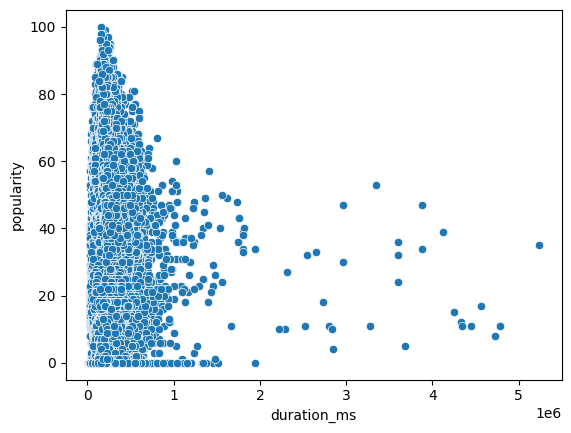

In [35]:
# Duration
sns.scatterplot(data = df, x = 'duration_ms', y = 'popularity')
plt.show()

Weaker Predictor: Slight negative realtionship (very long durations have low popularity)

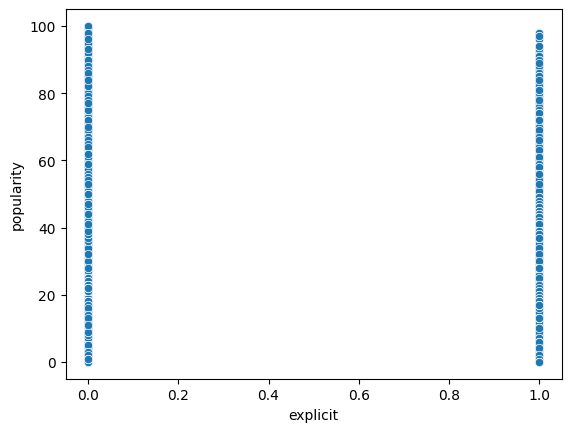

In [36]:
# Explicit
sns.scatterplot(data = df, x = 'explicit', y = 'popularity')
plt.show()

No relationship

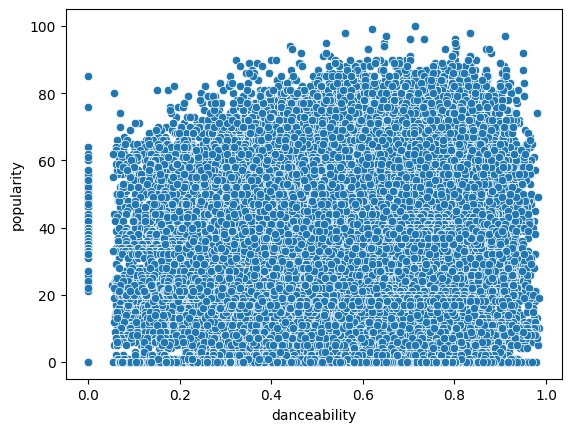

In [37]:
# Danceability
sns.scatterplot(data = df, x = 'danceability', y = 'popularity')
plt.show()

Very weak: very slight positive trend

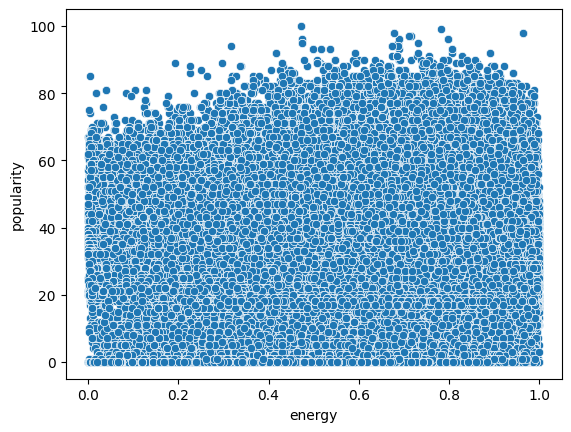

In [38]:
# Energy
sns.scatterplot(data = df, x = 'energy', y = 'popularity')
plt.show()

Very weak: very slight positive trend

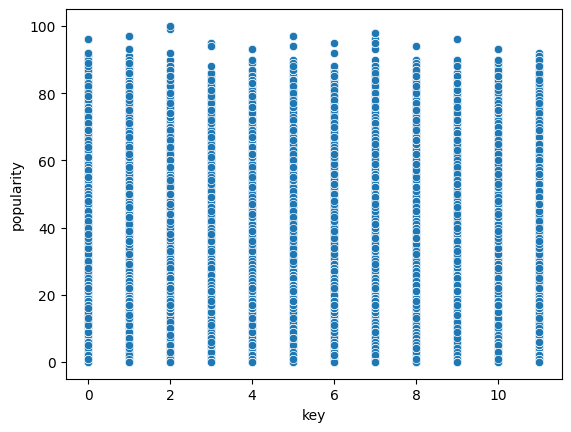

In [39]:
# Key
sns.scatterplot(data = df, x = 'key', y = 'popularity')
plt.show()

No relationship

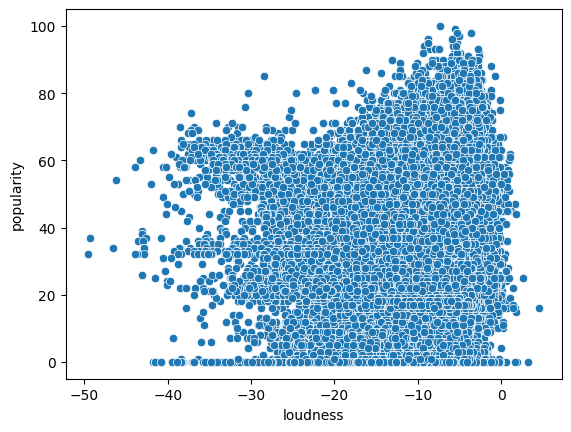

In [40]:
# Loudness
sns.scatterplot(data = df, x = 'loudness', y = 'popularity')
plt.show()

Strong predictor: Positive realtionship (as loudness increases, so does popularity)

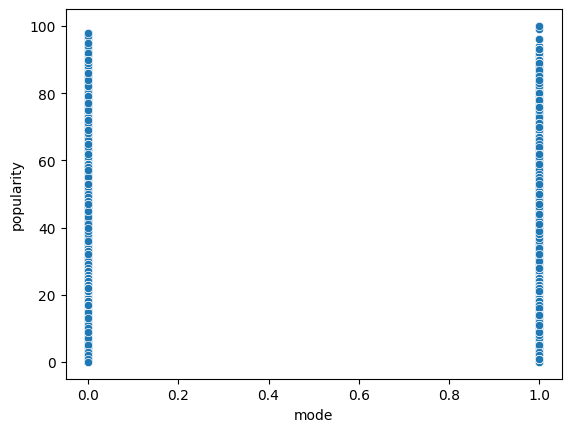

In [41]:
# Mode
sns.scatterplot(data = df, x = 'mode', y = 'popularity')
plt.show()

No relationship

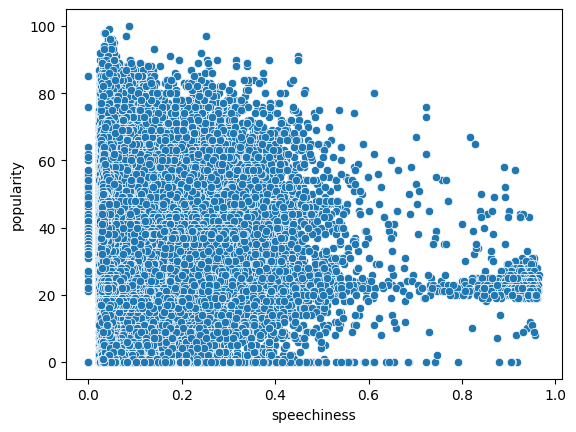

In [42]:
# Speechiness
sns.scatterplot(data = df, x = 'speechiness', y = 'popularity')
plt.show()

Strong predictor: Negative Relationsip (as speechiness increases, popularity decreases)

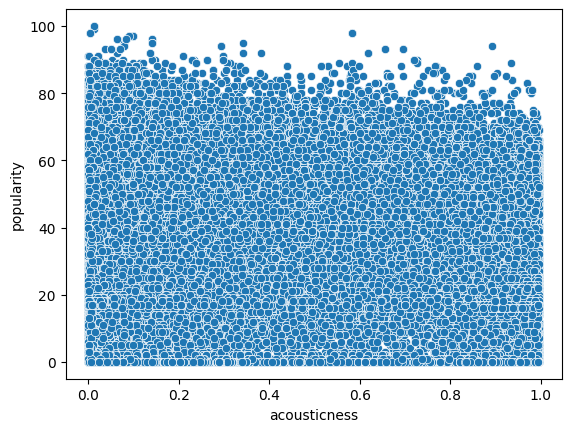

In [43]:
# Acousticness
sns.scatterplot(data = df, x = 'acousticness', y = 'popularity')
plt.show()

Very weak: very slight realtionship but not strong enough to be useful

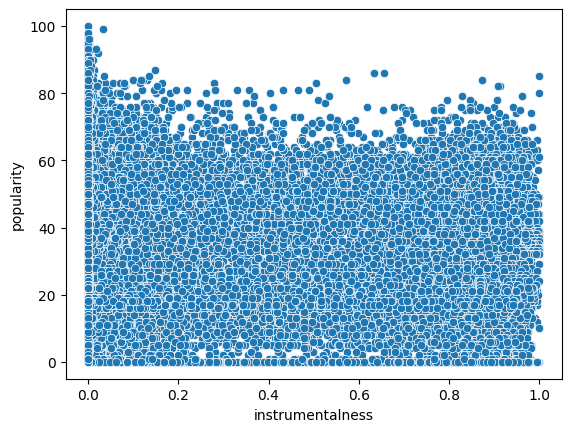

In [44]:
# Instrumentalness
sns.scatterplot(data = df, x = 'instrumentalness', y = 'popularity')
plt.show()

Very weak: very slight realtionship but not strong enough to be useful

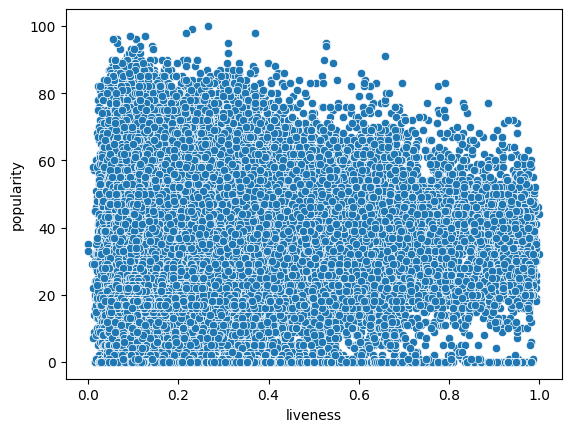

In [45]:
# Liveness
sns.scatterplot(data = df, x = 'liveness', y = 'popularity')
plt.show()

Moderate Predictor: Negative Relationship (as liveness increases, popularity decreases)

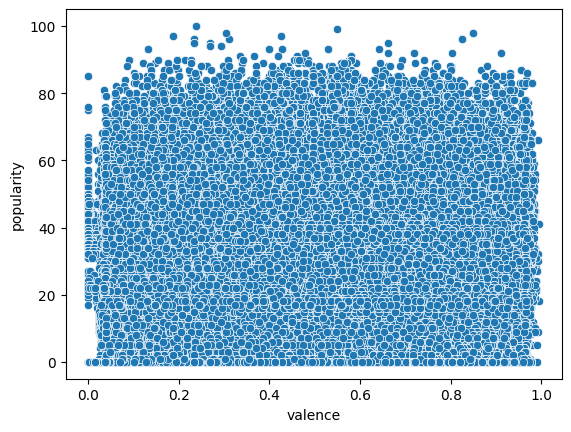

In [46]:
# Valence
sns.scatterplot(data = df, x = 'valence', y = 'popularity')
plt.show()

No relationship

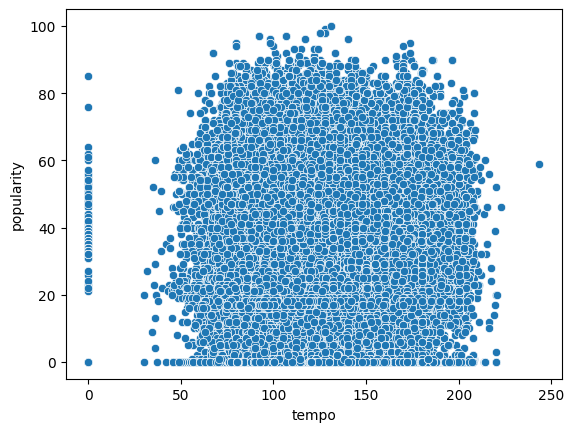

In [47]:
# Tempo
sns.scatterplot(data = df, x = 'tempo', y = 'popularity')
plt.show()

No relationship

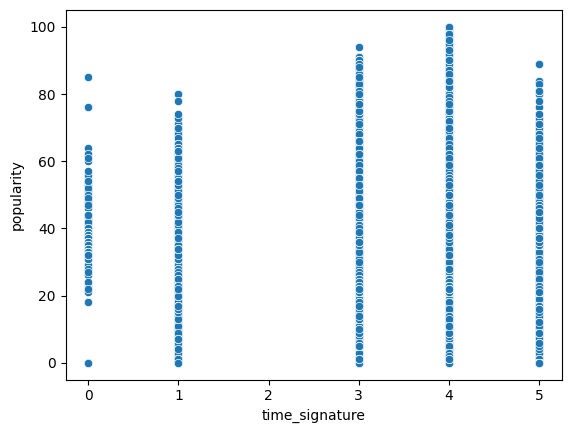

In [48]:
# Time Signature
sns.scatterplot(data = df, x = 'time_signature', y = 'popularity')
plt.show()

No relationship

Boxplots for Categorical Features

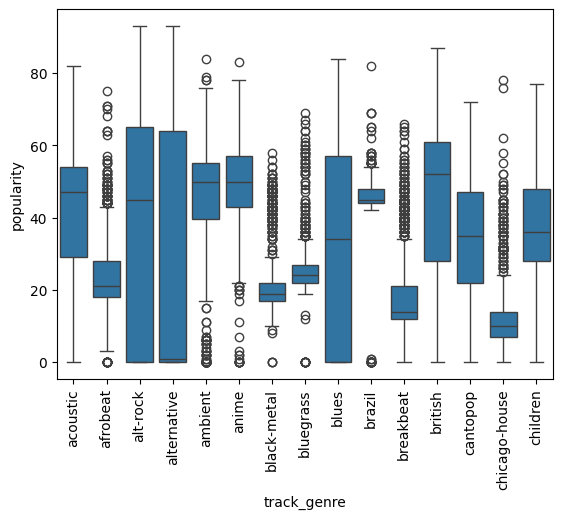

In [49]:
# Select Top Genres (too many in dataset to visualize)
top_genres = df['track_genre'].value_counts().nlargest(15).index

# Top Track Genres
sns.boxplot(data = df[df['track_genre'].isin(top_genres)], x = 'track_genre', y = 'popularity')
plt.xticks(rotation = 90)
plt.show()

High variablity

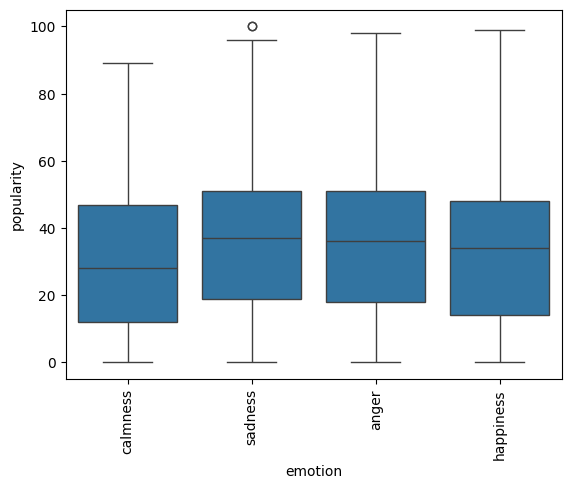

In [50]:
# Emotion (using one found to be more useful)
sns.boxplot(data = df, x = 'emotion', y = 'popularity')
plt.xticks(rotation = 90)
plt.show()

Very similar spread: Not helpful in determing popularity

Linear Regression

In [51]:
# Train/Test split

# Using Features with relationships from scatter plots
X = df[['liveness', 'speechiness', 'loudness', 'duration_ms']]
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [52]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
lr_mse = mean_squared_error(y_test, y_pred)
lr_r2 = r2_score(y_test, y_pred)

print("Linear MSE: ", lr_mse)
print("Linear R2: ", lr_r2)

Linear MSE:  493.7600936223611
Linear R2:  0.00439939649954646


Lasso Regression

In [53]:
# Train/Test Split

# Use all numerical features (automatic feature selection)
X = df.drop(columns = ['popularity', 'track_id', 'artists', 'album_name',
                       'track_name', 'track_genre', 'emotion', 'emotion_kmeans', 'cluster'])
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [54]:
# Lasso Regression
lasso = Lasso(alpha = 0.1)
lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)
lasso_mse = mean_squared_error(y_test, y_pred)
lasso_r2 = r2_score(y_test, y_pred)

print("Lasso MSE: ", lasso_mse)
print("Lasso R2: ", lasso_r2)

Lasso MSE:  486.9687316054833
Lasso R2:  0.018093261617299294


In [55]:
# Features kept in Lasso
coef_series = pd.Series(lasso.coef_, index = X.columns)
print(coef_series)

duration_ms        -0.000002
explicit            1.517025
danceability        1.762609
energy             -0.825772
key                -0.013305
loudness            0.120815
mode               -0.365425
speechiness        -3.678236
acousticness       -0.000000
instrumentalness   -6.378700
liveness           -0.000000
valence            -5.798102
tempo               0.008099
time_signature      0.812397
dtype: float64


Both Models have exteremly low R-squared values indicating that the audio features have poor predictive performance. A more complex model will be used to see if it can capture potential non-linear relationships

Gradient Boosting Regressor

In [56]:
# Same Train/Test split as Lassso
X = df.drop(columns = ['popularity', 'track_id', 'artists', 'album_name',
                       'track_name', 'track_genre', 'emotion', 'emotion_kmeans', 'cluster'])
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [57]:
# Gradient Boosting Regression
gbr = GradientBoostingRegressor(n_estimators = 100, random_state = 42)
gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)
gbr_mse = mean_squared_error(y_test, y_pred)
gbr_r2 = r2_score(y_test, y_pred)

print("Gradient Boosting MSE: ", gbr_mse)
print("Gradient Boosting R2: ", gbr_r2)

Gradient Boosting MSE:  450.7114849477751
Gradient Boosting R2:  0.09120110714782015


GBR improved compared to Linear and Lasso Regression, but the R-squared value is still quite low. Even complex models struggle to predict popularity

Logistic Regression for Categorical Features

In [17]:
# Convert Popularity into binary variable
df['popular'] = (df['popularity'] > 60).astype(int)

Popularity was transformed into a binary value so logistic regrssion will run smoothly and cleanly. 1 - popular, 0 - not popular

Emotion

In [18]:
# Train/Test split
X = pd.get_dummies(df['emotion'], drop_first = True)
y = df['popular']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [19]:
# Logistic Regression for Emotion
log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred, zero_division= 0))
print("Logistic Regression Accuracy: ", accuracy)

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     30176
           1       0.00      0.00      0.00      4024

    accuracy                           0.88     34200
   macro avg       0.44      0.50      0.47     34200
weighted avg       0.78      0.88      0.83     34200

Logistic Regression Accuracy:  0.8823391812865498


Track Genre

In [20]:
# Only use top genres anaylzed in boxplot
top_genres = df['track_genre'].value_counts().nlargest(15).index
df_genre = df[df['track_genre'].isin(top_genres)]

In [21]:
# Test/Train Split
X = pd.get_dummies(df_genre['track_genre'], drop_first = True)
y = df_genre['popular']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [22]:
# Logistic Regression for Track Genre
log_reg2 = LogisticRegression(max_iter = 1000)
log_reg2.fit(X_train, y_train)

y_pred2 = log_reg2.predict(X_test)
accuracy2 = accuracy_score(y_test, y_pred2)
print(classification_report(y_test, y_pred2, zero_division= 0))
print("Logistic Regression Accuracy: ", accuracy2)

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      4059
           1       0.00      0.00      0.00       441

    accuracy                           0.90      4500
   macro avg       0.45      0.50      0.47      4500
weighted avg       0.81      0.90      0.86      4500

Logistic Regression Accuracy:  0.902


In [23]:
# Check for class imbalance
print(df['popular'].value_counts(normalize = True))

popular
0    0.880964
1    0.119036
Name: proportion, dtype: float64


Logistic regression models using emotion and genre achieved high overall accuracy, but they recieved values of zero for precision, recall, and F1 score for the popular class. This means both models just predicted not popular every time. This is because the data is highly imbalanced, so these models are actually misleading.

Redo Logistic Regression by balancing the weights of each class

In [24]:
# Emotion
X = pd.get_dummies(df['emotion'], drop_first = True)
y = df['popular']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

log_reg = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))
print("Logistic Regression Accuracy: ", accuracy)

              precision    recall  f1-score   support

           0       0.90      0.28      0.43     30176
           1       0.12      0.76      0.21      4024

    accuracy                           0.34     34200
   macro avg       0.51      0.52      0.32     34200
weighted avg       0.81      0.34      0.41     34200

Logistic Regression Accuracy:  0.34137426900584794


In [25]:
# Track Genre
X = pd.get_dummies(df_genre['track_genre'], drop_first = True)
y = df_genre['popular']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

log_reg2 = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
log_reg2.fit(X_train, y_train)

y_pred2 = log_reg2.predict(X_test)
accuracy2 = accuracy_score(y_test, y_pred2)
print(classification_report(y_test, y_pred2, zero_division= 0))
print("Logistic Regression Accuracy: ", accuracy2)

              precision    recall  f1-score   support

           0       0.98      0.64      0.78      4059
           1       0.21      0.88      0.34       441

    accuracy                           0.67      4500
   macro avg       0.60      0.76      0.56      4500
weighted avg       0.91      0.67      0.73      4500

Logistic Regression Accuracy:  0.6657777777777778


Now the models are predicting popularity, but the low precision scores for the popular class indicate that the models are overpredicting the popular class. Track genre was proven to be important for predicting popularity, but the model is still not strong enough for track genre alone to effectively predict popularity.